# GCN Pipeline — Train on WelFake → Predict on FakeNews

**Pipeline đầy đủ trong một notebook:**

```
WELFake_Dataset.csv         true.csv + fake.csv
       │                            │
       ▼                            │
 [1] Load & Preprocess              │
       │                            │
       ▼                            │
 [2] TF-IDF + KNN Graph             │
       │                            │
       ▼                            │
 [3] Train GCN Model                │
       │                            │
       ▼                            │
 [4] Evaluate on WelFake Test       │
       │                            │
       ▼                            ▼
 [5] Save Checkpoint ──→ [6] Load & Preprocess FakeNews
                                    │
                                    ▼
                            [7] TF-IDF + KNN Graph
                                    │
                                    ▼
                            [8] GCN Inference
                                    │
                                    ▼
                            [9] Cross-Dataset Evaluation
```

---
# 🏋️ PHẦN 1 — TRAINING TRÊN WELFAKE

## ⚙️ Cell 0 — Import thư viện & Cấu hình

In [1]:
import sys
import string
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, accuracy_score, confusion_matrix
)
from scipy.sparse import csr_matrix

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from torch_geometric.data import Data

print(f"PyTorch version : {torch.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device          : {DEVICE}")

PyTorch version : 2.8.0
CUDA available  : False
Device          : cpu


In [2]:
# ── Tự động tìm PROJECT_ROOT ─────────────────────────────────────────────────
cwd = Path('.').resolve()
PROJECT_ROOT = cwd
for _ in range(4):
    if (PROJECT_ROOT / 'data').exists():
        break
    PROJECT_ROOT = PROJECT_ROOT.parent

RAW_DIR    = PROJECT_ROOT / 'data' / 'raw'
CKPT_DIR   = PROJECT_ROOT / 'output' / 'checkpoints'
CKPT_DIR.mkdir(parents=True, exist_ok=True)

CHECKPOINT   = CKPT_DIR / 'gcn_welfake.pt'
WELFAKE_PATH = RAW_DIR / 'WELFake_Dataset.csv'
FAKE_PATH    = RAW_DIR / 'fake.csv'
TRUE_PATH    = RAW_DIR / 'true.csv'

print(f"PROJECT_ROOT  : {PROJECT_ROOT}")
print(f"WELFake       : {WELFAKE_PATH}  (exists={WELFAKE_PATH.exists()})")
print(f"fake.csv      : {FAKE_PATH}   (exists={FAKE_PATH.exists()})")
print(f"true.csv      : {TRUE_PATH}   (exists={TRUE_PATH.exists()})")
print(f"Checkpoint    : {CHECKPOINT}")

if not WELFAKE_PATH.exists():
    raise FileNotFoundError(
        f"❌ WELFake_Dataset.csv not found in {RAW_DIR}."
    )
if not FAKE_PATH.exists() or not TRUE_PATH.exists():
    raise FileNotFoundError(
        f"❌ FakeNews CSV not found in {RAW_DIR}. Place fake.csv and true.csv there."
    )

PROJECT_ROOT  : /Users/macbook/Documents/HK2_Nam3(2526)/Theory/Graph Mining/Fake-News-Detection-GNN
WELFake       : /Users/macbook/Documents/HK2_Nam3(2526)/Theory/Graph Mining/Fake-News-Detection-GNN/data/raw/WELFake_Dataset.csv  (exists=True)
fake.csv      : /Users/macbook/Documents/HK2_Nam3(2526)/Theory/Graph Mining/Fake-News-Detection-GNN/data/raw/fake.csv   (exists=True)
true.csv      : /Users/macbook/Documents/HK2_Nam3(2526)/Theory/Graph Mining/Fake-News-Detection-GNN/data/raw/true.csv   (exists=True)
Checkpoint    : /Users/macbook/Documents/HK2_Nam3(2526)/Theory/Graph Mining/Fake-News-Detection-GNN/output/checkpoints/gcn_welfake.pt


In [7]:
# ── Hyperparameters ───────────────────────────────────────────────────────────
SAMPLE_SIZE   = 44898    # Số WelFake articles dùng để train (-1 = toàn bộ)
MAX_FEATURES  = 2000    # Số chiều TF-IDF
KNN_K         = 5       # Số hàng xóm KNN
HIDDEN_DIM    = 128     # Hidden channels của GCN
EPOCHS        = 100     # Số epoch train
LR            = 0.001   # Learning rate
TEST_RATIO    = 0.2     # Tỷ lệ tập test
RANDOM_SEED   = 42

FAKENEWS_SAMPLE_SIZE = 3000  # Số articles FakeNews dùng để predict

print(f"SAMPLE_SIZE   : {SAMPLE_SIZE}")
print(f"MAX_FEATURES  : {MAX_FEATURES}")
print(f"KNN_K         : {KNN_K}")
print(f"HIDDEN_DIM    : {HIDDEN_DIM}")
print(f"EPOCHS        : {EPOCHS}")
print(f"LR            : {LR}")

SAMPLE_SIZE   : 44898
MAX_FEATURES  : 2000
KNN_K         : 5
HIDDEN_DIM    : 128
EPOCHS        : 100
LR            : 0.001


---
## 📂 Step 1 — Load & Preprocess WelFake Dataset

In [8]:
print("=" * 60)
print("STEP 1: Loading WelFake Dataset")
print("=" * 60)

welfake_df = pd.read_csv(WELFAKE_PATH)
print(f"  ✓ Total WelFake articles: {len(welfake_df):,}")
print(f"  ✓ Columns: {list(welfake_df.columns)}")

welfake_df = welfake_df.dropna(subset=['title', 'text', 'label']).reset_index(drop=True)
print(f"  ✓ After dropna: {len(welfake_df):,} articles")

STEP 1: Loading WelFake Dataset
  ✓ Total WelFake articles: 72,134
  ✓ Columns: ['title', 'text', 'label']
  ✓ After dropna: 71,537 articles


In [9]:
# ── Text preprocessing ───────────────────────────────────────────────────────
def preprocess_text(text: str) -> str:
    """Lowercase, remove punctuation, normalize whitespace."""
    text = str(text).lower()
    text = text.translate(str.maketrans('', '', string.punctuation))
    return ' '.join(text.split())

welfake_df['text']    = welfake_df['text'].astype(str).apply(preprocess_text)
welfake_df['title']   = welfake_df['title'].astype(str).apply(preprocess_text)
welfake_df['content'] = welfake_df['title'] + " " + welfake_df['text']

# ── Sampling ─────────────────────────────────────────────────────────────────
if SAMPLE_SIZE < 0:
    df_sample = welfake_df.reset_index(drop=True)
    print(f"  ✓ Using ALL {len(df_sample):,} WelFake articles")
else:
    df_sample = welfake_df.sample(
        n=min(SAMPLE_SIZE, len(welfake_df)), random_state=RANDOM_SEED
    ).reset_index(drop=True)
    print(f"  ✓ Sampled {len(df_sample):,} WelFake articles")

y_data = df_sample['label'].values.astype(int)
fake_count = (y_data == 1).sum()
real_count = (y_data == 0).sum()
print(f"  ✓ Real: {real_count} ({real_count/len(y_data)*100:.1f}%)")
print(f"  ✓ Fake: {fake_count} ({fake_count/len(y_data)*100:.1f}%)")

  ✓ Sampled 44,898 WelFake articles
  ✓ Real: 21969 (48.9%)
  ✓ Fake: 22929 (51.1%)


---
## 🧮 Step 2 — TF-IDF Feature Extraction & KNN Graph Construction

In [10]:
print("=" * 60)
print("STEP 2: Feature Extraction & Graph Construction")
print("=" * 60)

# TF-IDF
vectorizer   = TfidfVectorizer(max_features=MAX_FEATURES)
tfidf_matrix = vectorizer.fit_transform(df_sample['content']).toarray()
scaler       = StandardScaler()
tfidf_feats  = scaler.fit_transform(tfidf_matrix)
print(f"  ✓ TF-IDF shape : {tfidf_feats.shape}")

# Train/test split
indices = np.arange(len(df_sample))
train_idx, test_idx = train_test_split(
    indices, test_size=TEST_RATIO, random_state=RANDOM_SEED, stratify=y_data
)
train_mask = torch.zeros(len(df_sample), dtype=torch.bool)
test_mask  = torch.zeros(len(df_sample), dtype=torch.bool)
train_mask[train_idx] = True
test_mask[test_idx]   = True
print(f"  ✓ Train: {train_mask.sum().item():,} | Test: {test_mask.sum().item():,}")

# KNN graph
nbrs = NearestNeighbors(n_neighbors=KNN_K + 1, algorithm='auto', metric='cosine')
nbrs.fit(tfidf_feats)
distances, indices_knn = nbrs.kneighbors(tfidf_feats)

rows, cols = [], []
for i in range(tfidf_feats.shape[0]):
    for j in range(1, KNN_K + 1):
        rows.append(i)
        cols.append(indices_knn[i][j])

data_val   = np.ones(len(rows))
adj        = csr_matrix((data_val, (rows, cols)),
                         shape=(tfidf_feats.shape[0], tfidf_feats.shape[0]))
adj        = adj.maximum(adj.transpose())
coo        = adj.tocoo()
edge_index = torch.tensor(np.array([coo.row, coo.col]), dtype=torch.long)

n_nodes = adj.shape[0]
n_edges = adj.count_nonzero()
print(f"  ✓ Nodes          : {n_nodes:,}")
print(f"  ✓ Edges (undir.) : {n_edges:,}")
print(f"  ✓ Avg degree     : {n_edges / n_nodes:.2f}")

# PyG Data object
X_tensor = torch.tensor(tfidf_feats, dtype=torch.float32)
y_tensor = torch.tensor(y_data, dtype=torch.long)
pyg_data = Data(
    x=X_tensor,
    edge_index=edge_index,
    y=y_tensor,
    train_mask=train_mask,
    test_mask=test_mask
).to(DEVICE)

STEP 2: Feature Extraction & Graph Construction
  ✓ TF-IDF shape : (44898, 2000)
  ✓ Train: 35,918 | Test: 8,980
  ✓ Nodes          : 44,898
  ✓ Edges (undir.) : 373,407
  ✓ Avg degree     : 8.32


---
## 🏗️ Step 3 — Define & Train GCN Model

In [11]:
class GCNModel(nn.Module):
    """2-layer Graph Convolutional Network for binary classification."""

    def __init__(self, in_channels: int, hidden_channels: int = 128, out_channels: int = 2):
        super(GCNModel, self).__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)

    def forward(self, data: Data):
        x, edge_index = data.x, data.edge_index
        x = self.conv1(x, edge_index)
        x = torch.relu(x)
        x = self.conv2(x, edge_index)
        return x

In [12]:
print("=" * 60)
print("STEP 3: Training GCN Model")
print("=" * 60)

model     = GCNModel(in_channels=MAX_FEATURES, hidden_channels=HIDDEN_DIM).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
criterion = nn.CrossEntropyLoss()

train_losses, test_accs = [], []

for epoch in range(1, EPOCHS + 1):
    # Training
    model.train()
    optimizer.zero_grad()
    out  = model(pyg_data)
    loss = criterion(out[pyg_data.train_mask], pyg_data.y[pyg_data.train_mask])
    loss.backward()
    optimizer.step()
    train_losses.append(loss.item())

    # Evaluation
    model.eval()
    with torch.no_grad():
        pred = out.argmax(dim=1)
        acc  = (pred[pyg_data.test_mask] == pyg_data.y[pyg_data.test_mask]).float().mean().item()
    test_accs.append(acc)

    if epoch % 10 == 0 or epoch == 1:
        print(f"  Epoch {epoch:>3d}/{EPOCHS} | Loss: {loss.item():.4f} | Test Acc: {acc*100:.2f}%")

print(f"\n  ✅ Training complete! Best Test Acc: {max(test_accs)*100:.2f}%")

STEP 3: Training GCN Model
  Epoch   1/100 | Loss: 0.7570 | Test Acc: 48.63%
  Epoch  10/100 | Loss: 0.3876 | Test Acc: 83.07%
  Epoch  20/100 | Loss: 0.3347 | Test Acc: 85.38%
  Epoch  30/100 | Loss: 0.3089 | Test Acc: 85.88%
  Epoch  40/100 | Loss: 0.2896 | Test Acc: 86.78%
  Epoch  50/100 | Loss: 0.2734 | Test Acc: 87.03%
  Epoch  60/100 | Loss: 0.2587 | Test Acc: 87.35%
  Epoch  70/100 | Loss: 0.2447 | Test Acc: 87.53%
  Epoch  80/100 | Loss: 0.2312 | Test Acc: 87.74%
  Epoch  90/100 | Loss: 0.2181 | Test Acc: 87.80%
  Epoch 100/100 | Loss: 0.2056 | Test Acc: 87.81%

  ✅ Training complete! Best Test Acc: 87.87%


---
## 📊 Step 4 — Evaluate on WelFake Test Set

STEP 4: Evaluation on WelFake Test Set

  ✅ Test Accuracy: 0.8787 (87.87%)

              precision    recall  f1-score   support

    Real (0)       0.88      0.87      0.88      4394
    Fake (1)       0.88      0.89      0.88      4586

    accuracy                           0.88      8980
   macro avg       0.88      0.88      0.88      8980
weighted avg       0.88      0.88      0.88      8980



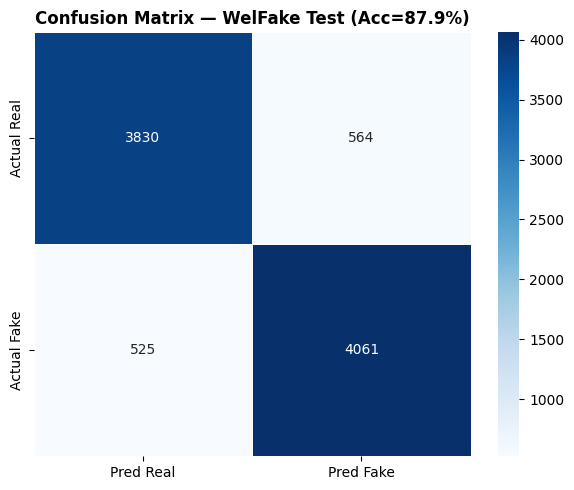

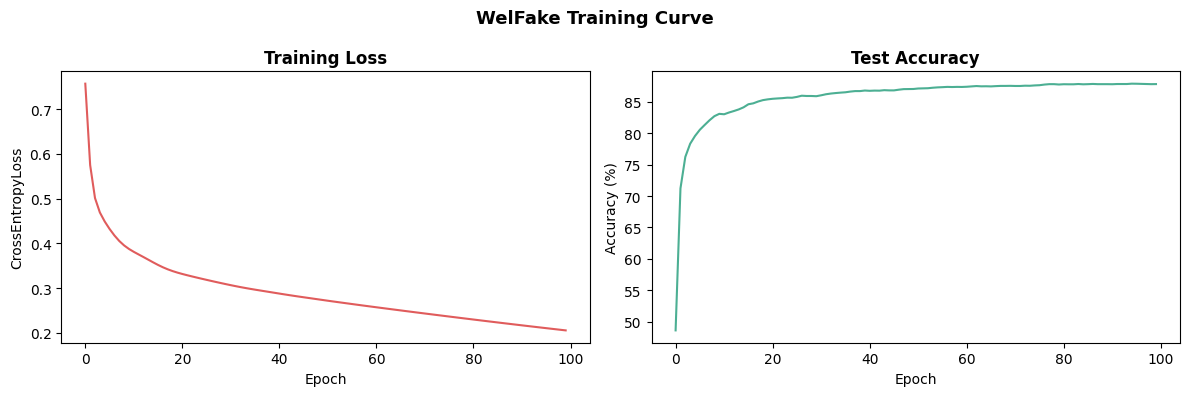

In [15]:
print("=" * 60)
print("STEP 4: Evaluation on WelFake Test Set")
print("=" * 60)

model.eval()
with torch.no_grad():
    out   = model(pyg_data)
    preds = out.argmax(dim=1).cpu().numpy()

y_test     = pyg_data.y[pyg_data.test_mask].cpu().numpy()
preds_test = preds[pyg_data.test_mask.cpu().numpy()]
test_acc   = accuracy_score(y_test, preds_test)

print(f"\n  ✅ Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)\n")
print(classification_report(y_test, preds_test, target_names=['Real (0)', 'Fake (1)']))

# Confusion matrix
cm = confusion_matrix(y_test, preds_test)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred Real', 'Pred Fake'],
            yticklabels=['Actual Real', 'Actual Fake'],
            ax=ax, linewidths=0.5, linecolor='white')
ax.set_title(f'Confusion Matrix — WelFake Test (Acc={test_acc*100:.1f}%)', fontweight='bold')
plt.tight_layout()
plt.show()

# Training curve
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(train_losses, color='#E05C5C', linewidth=1.5)
ax1.set_title('Training Loss', fontweight='bold')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('CrossEntropyLoss')
ax2.plot([a*100 for a in test_accs], color='#4CAF93', linewidth=1.5)
ax2.set_title('Test Accuracy', fontweight='bold')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy (%)')
plt.suptitle('WelFake Training Curve', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 💾 Step 5 — Save Checkpoint

In [16]:
print("=" * 60)
print("STEP 5: Saving Checkpoint")
print("=" * 60)

torch.save({
    'model_state_dict': model.state_dict(),
    'in_channels'     : MAX_FEATURES,
    'hidden_channels' : HIDDEN_DIM,
    'out_channels'    : 2,
    'test_accuracy'   : test_acc,
    'timestamp'       : datetime.now().isoformat(),
    'hyperparams'     : {
        'sample_size' : SAMPLE_SIZE,
        'max_features': MAX_FEATURES,
        'knn_k'       : KNN_K,
        'hidden_dim'  : HIDDEN_DIM,
        'epochs'      : EPOCHS,
        'learning_rate': LR,
    }
}, CHECKPOINT)

print(f"  ✓ Checkpoint saved to: {CHECKPOINT}")
print(f"  ✓ Test accuracy      : {test_acc*100:.2f}%")

STEP 5: Saving Checkpoint
  ✓ Checkpoint saved to: /Users/macbook/Documents/HK2_Nam3(2526)/Theory/Graph Mining/Fake-News-Detection-GNN/output/checkpoints/gcn_welfake.pt
  ✓ Test accuracy      : 87.87%


---
# 🔮 PHẦN 2 — CROSS-DATASET INFERENCE TRÊN FAKENEWS

> Model **đã được train** ở Phần 1 sẽ được dùng trực tiếp (không cần load lại checkpoint).
> TF-IDF được fit lại trên FakeNews với cùng `max_features` để đảm bảo input dimension khớp.

---
## 📂 Step 6 — Load & Preprocess FakeNews Dataset

In [17]:
print("=" * 60)
print("STEP 6: Loading FakeNews Dataset")
print("=" * 60)

fake_df = pd.read_csv(FAKE_PATH)
fake_df['label'] = 1  # 1 = Fake
print(f"  ✓ fake.csv : {len(fake_df):,} articles")

true_df = pd.read_csv(TRUE_PATH)
true_df['label'] = 0  # 0 = Real
print(f"  ✓ true.csv : {len(true_df):,} articles")

fn_combined = pd.concat([fake_df, true_df], ignore_index=True)
print(f"  ✓ Combined : {len(fn_combined):,} articles")

STEP 6: Loading FakeNews Dataset
  ✓ fake.csv : 23,481 articles
  ✓ true.csv : 21,417 articles
  ✓ Combined : 44,898 articles


In [18]:
fn_combined['text']    = fn_combined['text'].astype(str).apply(preprocess_text)
fn_combined['title']   = fn_combined['title'].astype(str).apply(preprocess_text)
fn_combined['content'] = fn_combined['title'] + " " + fn_combined['text']

# Sampling
if FAKENEWS_SAMPLE_SIZE < 0:
    fn_sample = fn_combined.reset_index(drop=True)
    print(f"  ✓ Using ALL {len(fn_sample):,} FakeNews articles")
else:
    fn_sample = fn_combined.sample(
        n=min(FAKENEWS_SAMPLE_SIZE, len(fn_combined)), random_state=RANDOM_SEED
    ).reset_index(drop=True)
    print(f"  ✓ Sampled {len(fn_sample):,} FakeNews articles")

y_fn = fn_sample['label'].values
fn_fake = (y_fn == 1).sum()
fn_real = (y_fn == 0).sum()
print(f"  ✓ Real: {fn_real} ({fn_real/len(y_fn)*100:.1f}%)")
print(f"  ✓ Fake: {fn_fake} ({fn_fake/len(y_fn)*100:.1f}%)")

  ✓ Sampled 3,000 FakeNews articles
  ✓ Real: 1397 (46.6%)
  ✓ Fake: 1603 (53.4%)


---
## 🧮 Step 7 — TF-IDF + KNN Graph on FakeNews

> ⚠️ **Lưu ý:** TF-IDF được fit lại trên FakeNews (inductive setting). Từ vựng khác nhau giữa 2 dataset là một trong những nguyên nhân chính làm giảm accuracy cross-dataset.

In [19]:
print("=" * 60)
print("STEP 7: Feature Extraction & Graph Construction (FakeNews)")
print("=" * 60)

# TF-IDF với cùng MAX_FEATURES
fn_vectorizer   = TfidfVectorizer(max_features=MAX_FEATURES)
fn_tfidf_matrix = fn_vectorizer.fit_transform(fn_sample['content']).toarray()
fn_scaler       = StandardScaler()
fn_tfidf_feats  = fn_scaler.fit_transform(fn_tfidf_matrix)
print(f"  ✓ TF-IDF shape : {fn_tfidf_feats.shape}")

# KNN graph
fn_nbrs = NearestNeighbors(n_neighbors=KNN_K + 1, algorithm='auto', metric='cosine')
fn_nbrs.fit(fn_tfidf_feats)
_, fn_indices_knn = fn_nbrs.kneighbors(fn_tfidf_feats)

fn_rows, fn_cols = [], []
for i in range(fn_tfidf_feats.shape[0]):
    for j in range(1, KNN_K + 1):
        fn_rows.append(i)
        fn_cols.append(fn_indices_knn[i][j])

fn_data_val   = np.ones(len(fn_rows))
fn_adj        = csr_matrix((fn_data_val, (fn_rows, fn_cols)),
                            shape=(fn_tfidf_feats.shape[0], fn_tfidf_feats.shape[0]))
fn_adj        = fn_adj.maximum(fn_adj.transpose())
fn_coo        = fn_adj.tocoo()
fn_edge_index = torch.tensor(np.array([fn_coo.row, fn_coo.col]), dtype=torch.long)

n_nodes_fn = fn_adj.shape[0]
n_edges_fn = fn_adj.count_nonzero()
print(f"  ✓ Nodes          : {n_nodes_fn:,}")
print(f"  ✓ Edges (undir.) : {n_edges_fn:,}")
print(f"  ✓ Avg degree     : {n_edges_fn / n_nodes_fn:.2f}")

STEP 7: Feature Extraction & Graph Construction (FakeNews)
  ✓ TF-IDF shape : (3000, 2000)
  ✓ Nodes          : 3,000
  ✓ Edges (undir.) : 21,399
  ✓ Avg degree     : 7.13


---
## 🔮 Step 8 — GCN Inference on FakeNews

In [20]:
print("=" * 60)
print("STEP 8: Inference on FakeNews")
print("=" * 60)

fn_X_tensor   = torch.tensor(fn_tfidf_feats, dtype=torch.float32).to(DEVICE)
fn_y_tensor   = torch.tensor(y_fn, dtype=torch.long).to(DEVICE)
fn_edge_dev   = fn_edge_index.to(DEVICE)

fn_pyg_data = Data(x=fn_X_tensor, edge_index=fn_edge_dev, y=fn_y_tensor)

start_time = datetime.now()
model.eval()  # Dùng model đã train ở Phần 1
with torch.no_grad():
    fn_out   = model(fn_pyg_data)
    fn_probs = torch.softmax(fn_out, dim=1).cpu().numpy()
    fn_preds = fn_out.argmax(dim=1).cpu().numpy()
    fn_true  = fn_y_tensor.cpu().numpy()

elapsed = (datetime.now() - start_time).total_seconds()
print(f"  ✓ Inference completed in {elapsed:.2f}s")
print(f"  ✓ Predicted {len(fn_preds):,} samples")
print(f"  ✓ Predicted Fake: {(fn_preds == 1).sum():,}  |  Predicted Real: {(fn_preds == 0).sum():,}")

STEP 8: Inference on FakeNews
  ✓ Inference completed in 0.02s
  ✓ Predicted 3,000 samples
  ✓ Predicted Fake: 1,764  |  Predicted Real: 1,236


---
## 📊 Step 9 — Cross-Dataset Evaluation (WelFake → FakeNews)

STEP 9: Cross-Dataset Evaluation Results

  ✅ Accuracy on FakeNews (cross-dataset): 0.6503 (65.03%)

              precision    recall  f1-score   support

    Real (0)       0.64      0.57      0.60      1397
    Fake (1)       0.66      0.72      0.69      1603

    accuracy                           0.65      3000
   macro avg       0.65      0.64      0.65      3000
weighted avg       0.65      0.65      0.65      3000



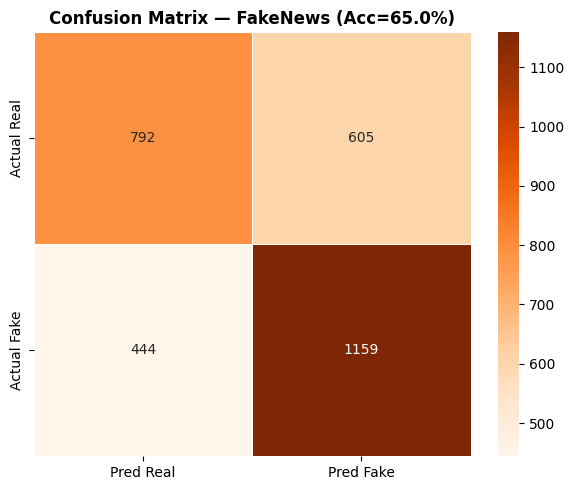

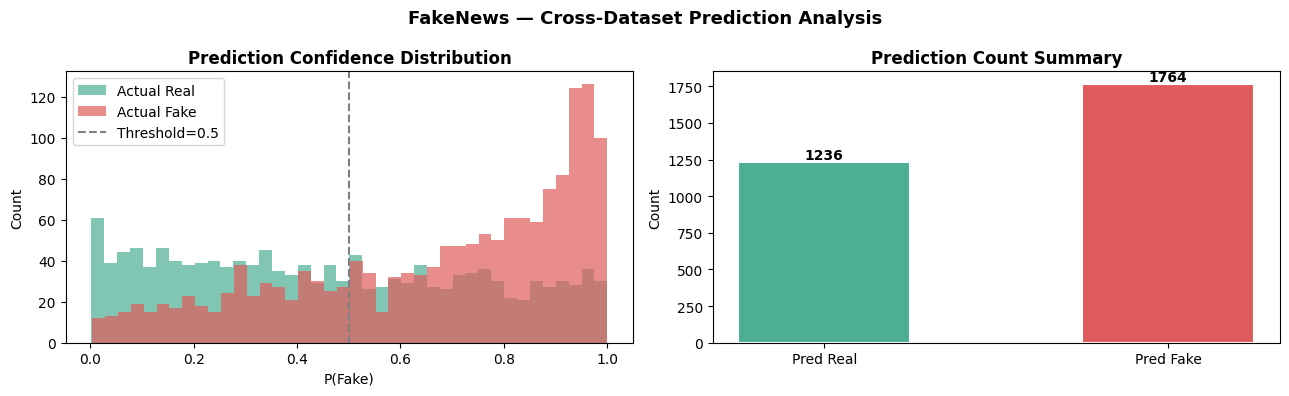

In [21]:
print("=" * 60)
print("STEP 9: Cross-Dataset Evaluation Results")
print("=" * 60)

fn_acc = accuracy_score(fn_true, fn_preds)
print(f"\n  ✅ Accuracy on FakeNews (cross-dataset): {fn_acc:.4f} ({fn_acc*100:.2f}%)\n")
print(classification_report(fn_true, fn_preds, target_names=['Real (0)', 'Fake (1)']))

# Confusion matrix
fn_cm = confusion_matrix(fn_true, fn_preds)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(fn_cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Pred Real', 'Pred Fake'],
            yticklabels=['Actual Real', 'Actual Fake'],
            ax=ax, linewidths=0.5, linecolor='white')
ax.set_title(f'Confusion Matrix — FakeNews (Acc={fn_acc*100:.1f}%)', fontweight='bold')
plt.tight_layout()
plt.show()

# Confidence distribution
fn_prob_fake = fn_probs[:, 1]
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(fn_prob_fake[fn_true == 0], bins=40, alpha=0.7, color='#4CAF93', label='Actual Real')
axes[0].hist(fn_prob_fake[fn_true == 1], bins=40, alpha=0.7, color='#E05C5C', label='Actual Fake')
axes[0].axvline(0.5, color='gray', linestyle='--', linewidth=1.5, label='Threshold=0.5')
axes[0].set_xlabel('P(Fake)'); axes[0].set_ylabel('Count')
axes[0].set_title('Prediction Confidence Distribution', fontweight='bold')
axes[0].legend()

pred_labels = ['Pred Real', 'Pred Fake']
pred_counts = [(fn_preds == 0).sum(), (fn_preds == 1).sum()]
axes[1].bar(pred_labels, pred_counts, color=['#4CAF93', '#E05C5C'],
            edgecolor='white', linewidth=1.5, width=0.5)
axes[1].set_title('Prediction Count Summary', fontweight='bold')
axes[1].set_ylabel('Count')
for i, v in enumerate(pred_counts):
    axes[1].text(i, v + 20, str(v), ha='center', fontweight='bold')

plt.suptitle('FakeNews — Cross-Dataset Prediction Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [22]:
# ── Tổng kết ─────────────────────────────────────────────────────────────────
tn, fp, fn, tp = fn_cm.ravel()
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

print(f"{'='*60}")
print(f"  📋 FULL PIPELINE SUMMARY")
print(f"{'='*60}")
print(f"  Train dataset    : WelFake ({SAMPLE_SIZE:,} samples)")
print(f"  Test dataset     : FakeNews ({len(fn_preds):,} samples)")
print(f"  WelFake Test Acc : {test_acc*100:.2f}%")
print(f"  FakeNews Accuracy: {fn_acc*100:.2f}%  (cross-dataset)")
print(f"  Precision (Fake) : {precision:.4f}")
print(f"  Recall (Fake)    : {recall:.4f}")
print(f"  F1-Score (Fake)  : {f1:.4f}")
print(f"{'='*60}")
print(f"  ✅ PIPELINE COMPLETED")
print(f"{'='*60}")

  📋 FULL PIPELINE SUMMARY
  Train dataset    : WelFake (44,898 samples)
  Test dataset     : FakeNews (3,000 samples)
  WelFake Test Acc : 87.87%
  FakeNews Accuracy: 65.03%  (cross-dataset)
  Precision (Fake) : 0.6570
  Recall (Fake)    : 0.7230
  F1-Score (Fake)  : 0.6884
  ✅ PIPELINE COMPLETED


---
## 🔎 Phân tích — Tại sao kết quả cross-dataset thường thấp hơn?

### 1. 🌍 Domain Shift
**WelFake** và **FakeNews** đến từ nguồn khác nhau:
- WelFake: 4 nguồn tổng hợp (Reuters, PolitiFact, WorldNews, WebText)
- FakeNews: Reuters + Politifact/scrapers, chủ yếu chính trị Mỹ 2015–2018

### 2. 📚 TF-IDF Vocabulary Mismatch
TF-IDF được fit lại trên FakeNews → 2000 từ quan trọng nhất của FakeNews ≠ 2000 từ model học từ WelFake.

> **Fix tiềm năng:** Lưu `vectorizer` từ lúc train WelFake và transform FakeNews bằng chính vectorizer đó.

### 3. 🕸️ GCN là mô hình Transductive
GCN học trên đồ thị cố định. Khi predict trên FakeNews, cả node features lẫn graph structure đều khác hoàn toàn.

> **Kiến trúc phù hợp hơn:** GraphSAGE, GAT — được thiết kế cho inductive learning.

### ✅ Hướng cải thiện
| Giải pháp | Mô tả |
|---|---|
| **Lưu vectorizer** | Dùng TF-IDF fit từ WelFake để transform FakeNews |
| **Inductive GNN** | GraphSAGE, GAT — học inductive |
| **Pretrained embeddings** | BERT/Sentence-BERT thay TF-IDF |
| **Multi-source training** | Train trên cả WelFake + FakeNews cùng lúc |
| **Few-shot fine-tuning** | Fine-tune model trên một phần nhỏ FakeNews |